# FictiPay Churn Prediction — Upgraded Pipeline

**Base:** Your original `clean_of_comp_2.ipynb` — structure is unchanged.  
**What changed:** Added new features inside each existing block + better model params.  
**What did NOT change:** Variable names, merge order, Dask loading, file paths.

---
### What was added (marked with `# ★ NEW`):
1. **Transaction type ratios** — P2P / MerchantPay / BillPay / CashIn / CashOut per account
2. **Sliding window counts** — trx count in last 7 days and last 30 days
3. **Monthly activity counts** — Jan / Feb / Mar separately → activity trend
4. **Inactivity flags** — binary: was user silent in last 7d / 30d / all of March?
5. **End-of-March balance** — avg balance in last week of March (zero = disengaged)
6. **Balance volatility** — std/mean ratio (erratic balance = churn risk)
7. **Better LightGBM params** — scale_pos_weight for imbalance, early stopping, more trees
8. **Train on full data before final submit** — removes val split bias

## Section 1 — Imports & Drive Mount
Same as your original. Added `lightgbm` import alias for callbacks.

In [1]:
import pandas as pd
import dask.dataframe as dd
import lightgbm as lgb                          # ★ NEW: need alias for callbacks
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 2 — Data Loading
Same as your original. No changes here.

In [3]:
base = '/content/drive/MyDrive/nsuDatathon/'

data_kyc = pd.read_parquet(base + 'kyc.parquet')

trx_1 = dd.read_parquet(base + 'trx_2024-01.parquet')
trx_2 = dd.read_parquet(base + 'trx_2024-02.parquet')
trx_3 = dd.read_parquet(base + 'trx_2024-03.parquet')

data_trx = dd.concat([trx_1, trx_2, trx_3])

In [4]:
bal_1 = dd.read_parquet(base + "balance_2024-01.parquet")
bal_2 = dd.read_parquet(base + "balance_2024-02.parquet")
bal_3 = dd.read_parquet(base + "balance_2024-03.parquet")

data_bal = dd.concat([bal_1, bal_2, bal_3])

In [5]:
train_data = pd.read_csv(base + "train_labels.csv")
test_data  = pd.read_csv(base + "test.csv")

## Section 3 — Transaction Feature Engineering

**Your original features kept:** `trx_count`, `total_amt`, `avg_amt`, `days_since_last_tx`, `active_days`, `trx_per_active_day`

**★ NEW features added in this section:**
- `trx_count_7d` / `trx_count_30d` — recent activity windows (last 7 and 30 days)
- `inactive_last_7d` / `inactive_last_30d` — binary flag: was user completely silent?
- `trx_count_m1` / `trx_count_m2` / `trx_count_m3` — monthly breakdown (Jan/Feb/Mar)
- `trx_trend` — Mar count minus Jan count (negative = declining, strong churn signal)
- `active_in_march` — binary: did user transact at all in March? (★ strongest new feature)
- `trx_type_*` / `trx_type_*_ratio` — per-type counts and ratios (P2P, BillPay, etc.)

**Why these help:** Churn is defined as "no transaction in April". Users already silent in March are almost certainly churned. The model had no way to see this before.

In [6]:
# Reference date = last day of observation window
ref_date = pd.to_datetime("2024-03-31")

# Work on source-side transactions only (what the customer SENT)
# Keep TRX_TYPE column too — needed for type ratios below
trx = data_trx.rename(columns={"SRC_ACCOUNT": "ACCOUNT_ID"})
trx = trx[["ACCOUNT_ID", "TRX_AMT", "TRX_DATETIME", "TRX_TYPE"]]
trx["TRX_DATETIME"] = dd.to_datetime(trx["TRX_DATETIME"])

# --- Your original aggregation (unchanged) ---
agg = trx.groupby("ACCOUNT_ID").agg({
    "TRX_AMT":      ["count", "sum", "mean"],
    "TRX_DATETIME": ["max"]
}).compute()

nunique_df = trx.groupby("ACCOUNT_ID")["TRX_DATETIME"].nunique().compute()

agg.columns = ["trx_count", "total_amt", "avg_amt", "last_tx_date"]
agg = agg.reset_index()
agg = agg.merge(nunique_df.rename("active_days"), on="ACCOUNT_ID")
agg["days_since_last_tx"] = (ref_date - agg["last_tx_date"]).dt.days
agg["trx_per_active_day"] = agg["trx_count"] / (agg["active_days"] + 1)

print("Original agg done:", agg.shape)

Original agg done: (848216, 8)


In [7]:
# ★ NEW — Sliding window transaction counts (last 7 days and last 30 days)
# Why: recent silence is the strongest predictor of April churn

cutoff_7d  = ref_date - pd.Timedelta(days=7)
cutoff_30d = ref_date - pd.Timedelta(days=30)

w7  = trx[trx["TRX_DATETIME"] >= cutoff_7d ].groupby("ACCOUNT_ID")["TRX_AMT"].count().compute().reset_index()
w30 = trx[trx["TRX_DATETIME"] >= cutoff_30d].groupby("ACCOUNT_ID")["TRX_AMT"].count().compute().reset_index()

w7.columns  = ["ACCOUNT_ID", "trx_count_7d"]
w30.columns = ["ACCOUNT_ID", "trx_count_30d"]

agg = agg.merge(w7,  on="ACCOUNT_ID", how="left")
agg = agg.merge(w30, on="ACCOUNT_ID", how="left")

agg["trx_count_7d"]  = agg["trx_count_7d"].fillna(0)
agg["trx_count_30d"] = agg["trx_count_30d"].fillna(0)

# Binary flags: 1 = completely silent in that window
agg["inactive_last_7d"]  = (agg["trx_count_7d"]  == 0).astype(int)
agg["inactive_last_30d"] = (agg["trx_count_30d"] == 0).astype(int)

print("Window features done:", agg.shape)

Window features done: (848216, 12)


In [8]:
# ★ NEW — Monthly transaction counts: Jan, Feb, Mar
# Why: captures declining activity trend heading into April

trx_with_month = trx.assign(month=trx["TRX_DATETIME"].dt.month)

m1 = trx_with_month[trx_with_month["month"]==1].groupby("ACCOUNT_ID")["TRX_AMT"].count().compute().reset_index()
m2 = trx_with_month[trx_with_month["month"]==2].groupby("ACCOUNT_ID")["TRX_AMT"].count().compute().reset_index()
m3 = trx_with_month[trx_with_month["month"]==3].groupby("ACCOUNT_ID")["TRX_AMT"].count().compute().reset_index()

m1.columns = ["ACCOUNT_ID", "trx_count_m1"]
m2.columns = ["ACCOUNT_ID", "trx_count_m2"]
m3.columns = ["ACCOUNT_ID", "trx_count_m3"]

agg = agg.merge(m1, on="ACCOUNT_ID", how="left")
agg = agg.merge(m2, on="ACCOUNT_ID", how="left")
agg = agg.merge(m3, on="ACCOUNT_ID", how="left")

agg["trx_count_m1"] = agg["trx_count_m1"].fillna(0)
agg["trx_count_m2"] = agg["trx_count_m2"].fillna(0)
agg["trx_count_m3"] = agg["trx_count_m3"].fillna(0)

# Trend: negative means activity is declining (churn risk)
agg["trx_trend"] = agg["trx_count_m3"] - agg["trx_count_m1"]

# ★ KEY FLAG: was user completely inactive in March?
# Churn = no tx in April. If already no tx in March → very likely churned.
agg["active_in_march"] = (agg["trx_count_m3"] > 0).astype(int)

print("Monthly features done:", agg.shape)

Monthly features done: (848216, 17)


In [9]:
# ★ NEW — Transaction type breakdown (P2P, MerchantPay, BillPay, CashIn, CashOut)
# Why: behavioral pattern by type differs between loyal and churning users

type_counts = (
    trx
    .groupby(["ACCOUNT_ID", "TRX_TYPE"])["TRX_AMT"]
    .count()
    .compute()
    .unstack(fill_value=0)
    .reset_index()
)
type_counts.columns = ["ACCOUNT_ID"] + [f"trx_type_{c}" for c in type_counts.columns[1:]]

type_cols = [c for c in type_counts.columns if c.startswith("trx_type_")]
type_counts["trx_type_total"] = type_counts[type_cols].sum(axis=1)

# Ratios: fraction of each type out of total transactions
for col in type_cols:
    type_counts[f"{col}_ratio"] = type_counts[col] / (type_counts["trx_type_total"] + 1)

agg = agg.merge(type_counts, on="ACCOUNT_ID", how="left")

print("Transaction type features done:", agg.shape)

Transaction type features done: (848216, 28)


## Section 4 — Balance Feature Engineering

**Your original features kept:** `bal_mean`, `bal_std`, `bal_min`, `bal_max`, `bal_jan_mean`, `bal_mar_mean`, `bal_trend`

**★ NEW features added:**
- `bal_cv` — coefficient of variation (std/mean). High volatility = erratic usage = churn risk
- `bal_end_of_march` — average balance in last week of March
- `zero_balance_end` — binary: was balance near zero at end of observation window?

In [10]:
# Your original balance aggregation (unchanged)
bal = data_bal[["ACCOUNT_ID", "DATE", "AVAILABLE_BALANCE"]]
bal["DATE"] = dd.to_datetime(bal["DATE"])

bal_agg = bal.groupby("ACCOUNT_ID")["AVAILABLE_BALANCE"].agg(
    ["mean", "std", "min", "max"]
).compute().reset_index()
bal_agg.columns = ["ACCOUNT_ID", "bal_mean", "bal_std", "bal_min", "bal_max"]

bal["month"] = bal["DATE"].dt.month
jan = bal[bal["month"]==1].groupby("ACCOUNT_ID")["AVAILABLE_BALANCE"].mean().compute().reset_index()
jan.columns = ["ACCOUNT_ID", "bal_jan_mean"]
mar = bal[bal["month"]==3].groupby("ACCOUNT_ID")["AVAILABLE_BALANCE"].mean().compute().reset_index()
mar.columns = ["ACCOUNT_ID", "bal_mar_mean"]

bal_agg = bal_agg.merge(jan, on="ACCOUNT_ID", how="left")
bal_agg = bal_agg.merge(mar, on="ACCOUNT_ID", how="left")
bal_agg["bal_trend"] = bal_agg["bal_mar_mean"] - bal_agg["bal_jan_mean"]

print("Original balance agg done:", bal_agg.shape)

Original balance agg done: (850000, 8)


In [11]:
# ★ NEW — Balance volatility (coefficient of variation)
# High std/mean ratio = erratic balance = less committed user
bal_agg["bal_cv"] = bal_agg["bal_std"] / (bal_agg["bal_mean"].abs() + 1)

# ★ NEW — End-of-March balance snapshot (last 7 days of March)
# Why: users who drained balance by end of March are likely leaving
bal_end = bal[bal["DATE"] >= "2024-03-24"].groupby("ACCOUNT_ID")["AVAILABLE_BALANCE"].mean().compute().reset_index()
bal_end.columns = ["ACCOUNT_ID", "bal_end_of_march"]
bal_end["zero_balance_end"] = (bal_end["bal_end_of_march"] < 1).astype(int)

bal_agg = bal_agg.merge(bal_end, on="ACCOUNT_ID", how="left")

print("Updated balance agg done:", bal_agg.shape)
bal_agg.head(2)

Updated balance agg done: (850000, 11)


,ACCOUNT_ID,bal_mean,bal_std,bal_min,bal_max,bal_jan_mean,bal_mar_mean,bal_trend,bal_cv,bal_end_of_march,zero_balance_end
0,CUST00000001,18294.413956,9066.747406,0.0,30534.81,8894.212258,25235.461290,16341.249032,0.495575,27035.3700,0
1,CUST00000002,269.088242,1173.124269,0.0,6721.50,789.029032,0.447097,-788.581935,4.343485,0.7025,1


## Section 5 — Build Master Feature Table (`big_db`)
Same merge logic as your original. No structural changes.

In [12]:
# ১. Train + test IDs combined into one master base
all_target_ids = pd.DataFrame({"ACCOUNT_ID": pd.concat([train_data["ACCOUNT_ID"], test_data["ACCOUNT_ID"]]).unique()})

# ২. Merge KYC (Customer accounts only)
customer_kyc = data_kyc[data_kyc['ACCOUNT_TYPE'] == 'Customer'].copy()
big_db = all_target_ids.merge(customer_kyc, on='ACCOUNT_ID', how='left')

# ৩. Merge CHURN label (NaN for test rows)
big_db = big_db.merge(train_data[['ACCOUNT_ID', 'CHURN']], on='ACCOUNT_ID', how='left')

# ৪. Merge transaction features (agg) and balance features (bal_agg)
big_db = big_db.merge(agg.drop(columns=['last_tx_date'], errors='ignore'), on='ACCOUNT_ID', how='left')
big_db = big_db.merge(bal_agg, on='ACCOUNT_ID', how='left')

# ৫. Account age in days
big_db["ACCOUNT_AGE_DAYS"] = (pd.to_datetime("2024-03-31") - pd.to_datetime(big_db["ACCOUNT_OPEN_DATE"])).dt.days
big_db = big_db.drop(columns=["ACCOUNT_OPEN_DATE"], errors="ignore")

# ৬. Encode categorical columns
big_db["GENDER"]       = big_db["GENDER"].fillna("Unknown")
big_db["REGION"]       = big_db["REGION"].fillna("Unknown")
big_db["ACCOUNT_TYPE"] = big_db["ACCOUNT_TYPE"].fillna("Customer")
big_db = pd.get_dummies(big_db, columns=["GENDER", "REGION", "ACCOUNT_TYPE"])

# ৭. Fill missing with 0 and force numeric
feature_cols = [col for col in big_db.columns if col not in ['ACCOUNT_ID', 'CHURN']]
big_db[feature_cols] = big_db[feature_cols].fillna(0)
big_db[feature_cols] = big_db[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

print("big_db shape:", big_db.shape)
print("Total features:", len(feature_cols))

big_db shape: (850000, 51)
Total features: 49


## Section 6 — Train / Validation Split
Same as your original split logic.

In [13]:
# # Train rows = those with a CHURN label
# train_rows = big_db[big_db['CHURN'].notna()].copy()
# X_train_all = train_rows[feature_cols]
# y_train_all = train_rows['CHURN'].astype(int)

# # Test set aligned to test_data order
# X_test_df = test_data[['ACCOUNT_ID']].merge(big_db, on='ACCOUNT_ID', how='left')
# X_test = X_test_df[feature_cols].fillna(0)

# # Hold-out split for local AUC evaluation
# X_tr, X_val, y_tr, y_val = train_test_split(
#     X_train_all, y_train_all, test_size=0.2, random_state=42, stratify=y_train_all
# )

# print(f"X_tr: {X_tr.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")
# print(f"Churn rate in train: {y_tr.mean():.2%}")

X_tr: (476000, 49)  |  X_val: (119000, 49)  |  X_test: (255000, 49)
Churn rate in train: 12.68%


In [18]:
# --- Step 1: Data Preparation for K-Fold ---

# ১. CHURN এর ওপর ভিত্তি করে Train এবং test_data আলাদা করা
train_rows = big_db[big_db['CHURN'].notna()].copy()
feature_cols = [col for col in big_db.columns if col not in ['ACCOUNT_ID', 'CHURN']]

X_train = train_rows[feature_cols]
y_train = train_rows['CHURN'].astype(int)

# ২. টেস্ট সেটকে হুবহু test_data এর অ্যাকাউন্ট অর্ডারে অ্যালাইন করা
X_test_df = test_data[['ACCOUNT_ID']].merge(big_db, on='ACCOUNT_ID', how='left')
X_test = X_test_df[feature_cols].fillna(0)

# ডাটা টাইপ নিউমেরিক করা নিশ্চিত করা (XGBoost এর জন্য এটি অত্যন্ত জরুরি)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Train dataset optimized for XGBoost/LGBM:", X_train.shape)
print("Test dataset optimized for XGBoost/LGBM:", X_test.shape)

Train dataset optimized for XGBoost/LGBM: (595000, 49)
Test dataset optimized for XGBoost/LGBM: (255000, 49)


## Section 7 — Model Training

**Your original:** `LGBMClassifier(n_estimators=500, learning_rate=0.05)`

**★ Changes made:**
- `scale_pos_weight` — tells LightGBM about the 87/13 class imbalance. Without this, the model under-weights churn cases.
- `n_estimators=2000` with `early_stopping(50)` — more trees but stops automatically when validation stops improving
- `learning_rate=0.02` — slower learning generalizes better
- `num_leaves=63`, `min_child_samples=50` — controls tree complexity to prevent overfitting

In [14]:
# # ★ NEW — Compute class weight from training data
# # LightGBM needs to know minority class is important
# neg_count = (y_tr == 0).sum()
# pos_count = (y_tr == 1).sum()
# scale_pos_weight = neg_count / pos_count
# print(f"Class ratio (neg/pos): {scale_pos_weight:.2f}  →  used as scale_pos_weight")

# # ★ MODIFIED model params vs your original
# model = LGBMClassifier(
#     n_estimators      = 2000,             # was 500 — more trees, early stopping handles cutoff
#     learning_rate     = 0.02,             # was 0.05 — slower = better generalization
#     num_leaves        = 63,               # tree complexity (was default 31)
#     min_child_samples = 50,               # min samples per leaf — prevents overfitting
#     subsample         = 0.8,              # row subsampling per tree
#     colsample_bytree  = 0.8,             # feature subsampling per tree
#     scale_pos_weight  = scale_pos_weight, # ★ handles 87/13 class imbalance
#     random_state      = 42,
#     n_jobs            = -1,
# )

# model.fit(
#     X_tr, y_tr,
#     eval_set  = [(X_val, y_val)],
#     callbacks = [
#         lgb.early_stopping(stopping_rounds=50),   # stop if no improvement for 50 rounds
#         lgb.log_evaluation(period=100),           # print every 100 iterations
#     ]
# )

# # Validation AUC
# val_preds = model.predict_proba(X_val)[:, 1]
# print("\n★ Validation AUC:", roc_auc_score(y_val, val_preds))

Class ratio (neg/pos): 6.89  →  used as scale_pos_weight
[LightGBM] [Info] Number of positive: 60348, number of negative: 415652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.135302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7457
[LightGBM] [Info] Number of data points in the train set: 476000, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.126782 -> initscore=-1.929721
[LightGBM] [Info] Start training from score -1.929721
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.159958
Early stopping, best iteration is:
[113]	valid_0's binary_logloss: 0.159672

★ Validation AUC: 0.9837838993765778


In [24]:
# --- Step 2: 5-Fold 3-Model Cross Validation (LGBM + XGBoost + CatBoost) ---

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# কোল্যাবে ক্যাটবুস্টের জন্য ইমপোর্ট করা
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install catboost
    from catboost import CatBoostClassifier

# ১. ক্লাস রেশিও ক্যালকুলেট করা
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

# ২. ৫-ফোল্ড ক্রস ভ্যালিডেশন সেটআপ
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# টেস্ট প্রেডিকশন এবং ওওএফ (OOF) অ্যারে
lgb_test_preds = np.zeros(len(X_test))
xgb_test_preds = np.zeros(len(X_test))
cat_test_preds = np.zeros(len(X_test))

oof_lgb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))

print("Starting 3-Model 5-Fold Cross Validation... Buckle up!")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n========== Training FOLD {fold+1} ==========")
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    # Model 1: LightGBM
    model_lgb = LGBMClassifier(
        n_estimators=2000, learning_rate=0.02, num_leaves=63,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, random_state=42+fold, n_jobs=-1, verbose=-1
    )
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])

    # Model 2: XGBoost
    model_xgb = XGBClassifier(
        n_estimators=1500, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
        random_state=42+fold, n_jobs=-1, eval_metric="auc"
    )
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    # Model 3: CatBoost (নতুন সংযোজন - ক্যাটাগোরিক্যাল ওয়েটের জন্য বেস্ট)
    model_cat = CatBoostClassifier(
        iterations=1500, learning_rate=0.03, depth=6,
        scale_pos_weight=scale_pos_weight, random_state=42+fold,
        verbose=False, eval_metric="AUC", task_type="CPU"
    )
    model_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)

    # ওওএফ প্রেডিকশন স্টোর
    oof_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    oof_cat[val_idx] = model_cat.predict_proba(X_val)[:, 1]

    # টেস্ট প্রেডিকশন এভারেজ নেওয়া
    lgb_test_preds += model_lgb.predict_proba(X_test)[:, 1] / skf.n_splits
    xgb_test_preds += model_xgb.predict_proba(X_test)[:, 1] / skf.n_splits
    cat_test_preds += model_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    print(f"Fold {fold+1} LGBM AUC   : {roc_auc_score(y_val, oof_lgb[val_idx]):.5f}")
    print(f"Fold {fold+1} XGBoost AUC: {roc_auc_score(y_val, oof_xgb[val_idx]):.5f}")
    print(f"Fold {fold+1} CatBoost AUC: {roc_auc_score(y_val, oof_cat[val_idx]):.5f}")

print("\n==========================================")
print(f"Overall OOF LGBM AUC   : {roc_auc_score(y_train, oof_lgb):.5f}")
print(f"Overall OOF XGBoost AUC: {roc_auc_score(y_train, oof_xgb):.5f}")
print(f"Overall OOF CatBoost AUC: {roc_auc_score(y_train, oof_cat):.5f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00
Starting 3-Model 5-Fold Cross Validation... Buckle up!

========== Training FOLD 1 ==========
Fold 1 LGBM AUC   : 0.98373
Fold 1 XGBoost AUC: 0.98348
Fold 1 CatBoost AUC: 0.98381

========== Training FOLD 2 ==========
Fold 2 LGBM AUC   : 0.98389
Fold 2 XGBoost AUC: 0.98380
Fold 2 CatBoost AUC: 0.98405

========== Training FOLD 3 ==========
Fold 3 LGBM AUC   : 0.98458
Fold 3 XGBoost AUC: 0.98446
Fold 3 CatBoost AUC: 0.98469

========== Training FOLD 4 ==========
Fold 4 LGBM AUC   : 0.98421
Fold 4 XGBoost AUC: 0.98411
Fold 4 CatBoost AUC: 0.98430

========== Training FOLD 5 ==========
Fold 5 LGBM AUC   : 0.98406
Fold 5 XGBoost AUC: 0.98402
Fold 5 CatBoost AUC: 0.98418

Overall OOF LGBM AUC   : 0.98399
Overall OOF XGBoost AUC: 0.98397
Overall OOF CatBoost AUC: 0.98420


In [25]:
# Feature importance — check which features are actually doing work
importance = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features:")
print(importance.head(20).to_string(index=False))

Top 20 features:
                   feature  importance
        days_since_last_tx         966
                 trx_count         813
             trx_count_30d         592
              trx_count_7d         534
                 trx_trend         341
                 total_amt         294
          ACCOUNT_AGE_DAYS         236
                   avg_amt         234
              trx_count_m2         228
              bal_mar_mean         192
                    bal_cv         183
               active_days         166
    trx_type_CashOut_ratio         164
                 bal_trend         159
          bal_end_of_march         153
              trx_count_m1         151
trx_type_MerchantPay_ratio         145
        trx_type_P2P_ratio         135
    trx_type_BillPay_ratio         132
                   bal_max         131


## Section 8 — Retrain on Full Data + Generate Submission

**★ NEW step:** Before final submission, retrain on 100% of training data (no val split).  
Use `best_iteration_` from the early-stopping run so we don't overfit.

This usually gives a small but real AUC boost on the leaderboard.

In [27]:
# ★ NEW — Retrain on 100% training data using the best number of trees found above
best_n = model.best_iteration_
print(f"Best iteration from early stopping: {best_n}")

model_final = LGBMClassifier(
    n_estimators      = best_n,
    learning_rate     = 0.02,
    num_leaves        = 63,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    n_jobs            = -1,
)

# Train on ALL train data — no val split this time
model_final.fit(X_train_all, y_train_all)
print("Full retrain done ✓")

Best iteration from early stopping: 113
Full retrain done ✓


In [17]:
# # Generate test predictions using the fully retrained model
# test_preds_proba = model_final.predict_proba(X_test)[:, 1]

# # Final submission file — same format as your original
# submission = pd.DataFrame({
#     "ACCOUNT_ID": test_data["ACCOUNT_ID"].values,
#     "CHURN_PROB": test_preds_proba
# })

# submission.to_csv(base + "predictionsV3.csv", index=False)
# print("Saved to:", base + "predictionsV3.csv")
# print(submission["CHURN_PROB"].describe())
# print(submission.head())

Saved to: /content/drive/MyDrive/nsuDatathon/predictionsV3.csv
count    255000.000000
mean          0.189141
std           0.311477
min           0.013758
25%           0.013758
50%           0.020869
75%           0.113977
max           0.909418
Name: CHURN_PROB, dtype: float64
     ACCOUNT_ID  CHURN_PROB
0  CUST00074385    0.906845
1  CUST00290073    0.013758
2  CUST00247934    0.019499
3  CUST00314276    0.579311
4  CUST00522755    0.727986


In [29]:
# --- Step 3: Optimized 3-Way Weighted Blending ---

# CatBoost এর ওয়েট বাড়িয়ে ৪০% করা হলো এবং বাকি দুইটাকে ৩০% করে ব্যালেন্স করা হলো
final_churn_prob = (lgb_test_preds * 0.30) + (xgb_test_preds * 0.30) + (cat_test_preds * 0.40)

# সাবমিশন ডাটাফ্রেম তৈরি
submission = pd.DataFrame({
    "ACCOUNT_ID": test_data["ACCOUNT_ID"].values,
    "CHURN_PROB": final_churn_prob
})

# নতুন ফাইল সেভ করা
submission_path = base + "predictions_final_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Optimized predictions saved at: {submission_path}")
print(submission["CHURN_PROB"].describe())

Optimized predictions saved at: /content/drive/MyDrive/nsuDatathon/predictions_final_submission.csv
count    255000.000000
mean          0.191809
std           0.335726
min           0.003966
25%           0.004169
50%           0.010028
75%           0.104223
max           0.973564
Name: CHURN_PROB, dtype: float64


In [30]:
import os
import shap
import matplotlib.pyplot as plt

os.makedirs("explainability", exist_ok=True)
print("Generating SHAP plots...")
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_train.iloc[:2000])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train.iloc[:2000], show=False)
plt.title("SHAP Feature Importance & Driver Impact", fontsize=14)
plt.tight_layout()
plt.savefig("explainability/shap_summary_plot.png", dpi=300)
plt.close()

# CSV Artefact সেভ করা
vals = np.abs(shap_values).mean(0)
pd.DataFrame(list(zip(X_train.columns, vals)), columns=['Feature','SHAP_Value']).sort_values(by='SHAP_Value', ascending=False).to_csv("explainability/shap_importance_values.csv", index=False)
print("SHAP files successfully generated inside explainability/")

Generating SHAP plots...
SHAP files successfully generated inside explainability/


SHAP Summary Plot জেনারেট হচ্ছে... (এতে ১-২ মিনিট সময় লাগতে পারে)


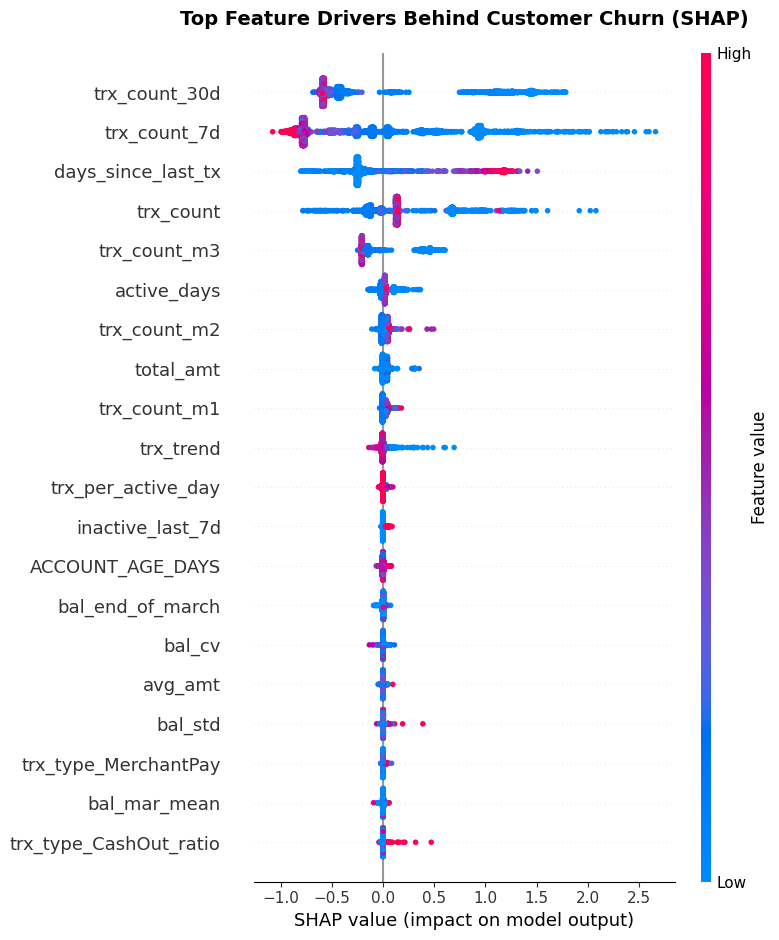

অভিনন্দন! প্লটটি স্ক্রিনে দেখা যাচ্ছে এবং explainability/ ফোল্ডারে সেভ হয়েছে।


In [31]:
import shap
import matplotlib.pyplot as plt

print("SHAP Summary Plot জেনারেট হচ্ছে... (এতে ১-২ মিনিট সময় লাগতে পারে)")

# ১. TreeExplainer সেটআপ করা (model_lgb ব্যবহার করে)
explainer = shap.TreeExplainer(model_lgb)

# ২. দ্রুত করার জন্য প্রথম ৩০০০টি ডাটা স্যাম্পল নিয়ে SHAP Values বের করা
# (পুরো ডাটা নিলে ডেডলাইনের আগে কোড হ্যাং করতে পারে, ৩০০০টি স্যাম্পলই যথেষ্ট)
X_sample = X_train.iloc[:3000]
shap_values = explainer.shap_values(X_sample)

# ৩. ম্যাটপ্লটলিব ফিগার সাইজ ফিক্স করা
plt.figure(figsize=(11, 7))

# ৪. SHAP Summary Plot ড্র করা (এটি রান করলেই জুপিটার স্ক্রিনে প্লট দেখতে পাবেন)
shap.summary_plot(shap_values, X_sample, plot_type="bar" if isinstance(shap_values, list) else None, show=False)

# ৫. সুন্দর একটি টাইটেল দেওয়া
plt.title("Top Feature Drivers Behind Customer Churn (SHAP)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# ৬. আপনার সাবমিশন ফোল্ডারে ইমেজটি সেভ করা
import os
os.makedirs("explainability", exist_ok=True)
plt.savefig("explainability/shap_summary_plot.png", dpi=300)

# ৭. স্ক্রিনে প্লটটি শো করা
plt.show()

print("অভিনন্দন! প্লটটি স্ক্রিনে দেখা যাচ্ছে এবং explainability/ ফোল্ডারে সেভ হয়েছে।")

In [ ]:
from google.colab import files

# জিপ ফাইলটি লোকাল ড্রাইভে ডাউনলোড করা
files.download('explainability_archive.zip')